In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("mxmh_survey_results.csv")
df_numeric = df[["Age","Hours per day", "BPM","Anxiety","Depression","Insomnia","OCD"]]


In [11]:
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


Корреляция Пирсона:
                     Age  Hours per day       BPM   Anxiety  Depression  \
Age            1.000000      -0.044638 -0.029928 -0.176662   -0.121563   
Hours per day -0.044638       1.000000  0.042554  0.049319    0.110527   
BPM           -0.029928       0.042554  1.000000 -0.027050    0.041371   
Anxiety       -0.176662       0.049319 -0.027050  1.000000    0.519969   
Depression    -0.121563       0.110527  0.041371  0.519969    1.000000   
Insomnia       0.006909       0.141821  0.053591  0.292669    0.378996   
OCD           -0.130114       0.118729  0.018927  0.348350    0.196988   

               Insomnia       OCD  
Age            0.006909 -0.130114  
Hours per day  0.141821  0.118729  
BPM            0.053591  0.018927  
Anxiety        0.292669  0.348350  
Depression     0.378996  0.196988  
Insomnia       1.000000  0.226354  
OCD            0.226354  1.000000  
Корреляция Спирмена:
                     Age  Hours per day       BPM   Anxiety  Depression  \
Ag

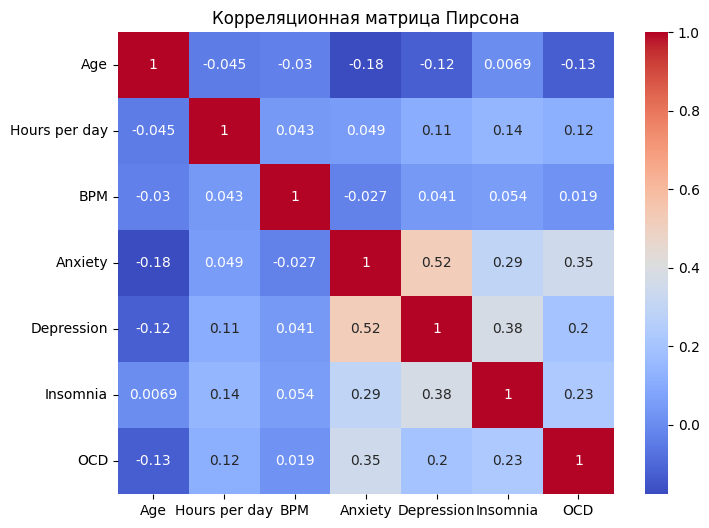

In [12]:
pearson_corr = df_numeric.corr(method='pearson')
spearman_corr = df_numeric.corr(method='spearman')
print("Корреляция Пирсона:\n", pearson_corr)
print("Корреляция Спирмена:\n", spearman_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Корреляционная матрица Пирсона")
plt.show()


                            OLS Regression Results                            
Dep. Variable:             Depression   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     8.058
Date:                Tue, 08 Apr 2025   Prob (F-statistic):            0.00617
Time:                        15:22:46   Log-Likelihood:                -127.67
No. Observations:                  62   AIC:                             259.3
Df Residuals:                      60   BIC:                             263.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3286      0.577      9.235      0.0

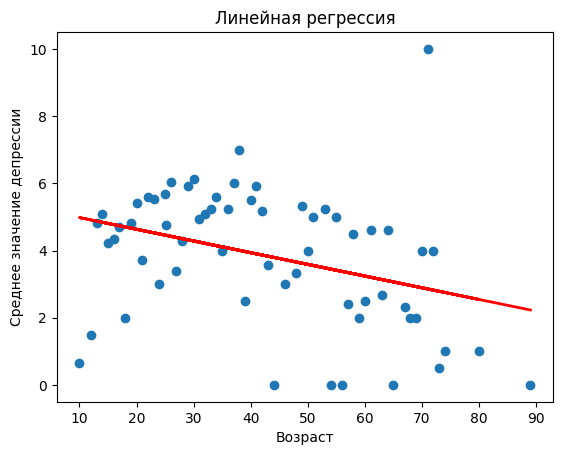

In [34]:
import statsmodels.api as sm
df["Depression"] = df["Depression"].fillna(df["Depression"].mean())
df["Age"] = df["Age"].fillna(df["Age"].mean())
# Предположим, что 'Independent_Variable' — столбец в df
# и 'Dependent_Variable' — целевая переменная
X = df['Age'].unique()  # Независимая переменная
Y = df['Depression'].groupby(by=df['Age']).mean() # Зависимая переменная
X = sm.add_constant(X) # Добавляем константу
model = sm.OLS(Y, X).fit() # Строим модель
print(model.summary()) # Сводная статистика
plt.scatter(X[:, 1], Y)
plt.plot(X[:, 1], model.predict(X),
linewidth=2, color = 'red')
plt.title("Линейная регрессия")
plt.xlabel("Возраст")
plt.ylabel("Среднее значение депрессии")
plt.show()